In [ ]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np

import config
from config import THICKNESS_VALUES, RAYLEIGH_ALPHA, RAYLEIGH_BETA


from beam_element import element_stiffness, element_mass, compute_section_properties
from assembly import generate_mesh, assemble_global_matrices, apply_boundary_conditions
from damping import build_rayleigh_damping, rayleigh_from_damping_ratios
from materials import get_material, list_materials, add_material


 STEP 1 — Generating parameter sets
Total possible combinations : 2048
Simulations requested       : 2048
  Parameter sets ready  : 2048

  Sample of first 3 simulations:
    sim 000 | steel      | L=  100 in | b=2.5 in | F0=   45 lbf
    sim 001 | aluminum   | L=  100 in | b=2.5 in | F0=   20 lbf
    sim 002 | aluminum   | L=  100 in | b=0.5 in | F0=   20 lbf

 STEP 2 — Running simulations in parallel
  Total simulations : 2048
  CPU cores         : -1 (-1 = all available)

Starting batch of 2048 simulations...
Using n_jobs = -1 (−1 means all CPU cores)



Simulations: 100%|██████████| 2048/2048 [01:41<00:00, 20.09sim/s]



Batch complete.
  Succeeded : 2048
  Failed    : 0

  Total time        : 103.25 s  (1.72 min)
  Time per sim      : 0.05 s
  Succeeded         : 2048
  Failed            : 0

 STEP 3 — Exporting one CSV per simulation
Exporting simulations to folder: 'simulation_results'
Encoding : C

Files exported : 2048
Files skipped  : 0 (failed simulations)
Output folder  : c:\Users\G_Modak\Desktop\PhD work\Trial 26 Feb 2026\simulation_results
Size per file  : ~4.06 MB
Total est size : ~8324.9 MB

Time vector saved : simulation_results\time_vector.csv
  Steps   : 2000
  t_start : 0.0 s
  t_end   : 1.0 s
  dt      : 0.0005 s

 STEP 4 — Summary statistics
  Total simulations  : 2048
  Succeeded          : 2048
  Failed             : 0
  Files exported     : 2048
  Output folder      : c:\Users\G_Modak\Desktop\PhD work\Trial 26 Feb 2026\simulation_results

  Material distribution:
    aluminum     : 1024 simulations
    steel        : 1024 simulations

  Length distribution:
    L =    50 in  : 256

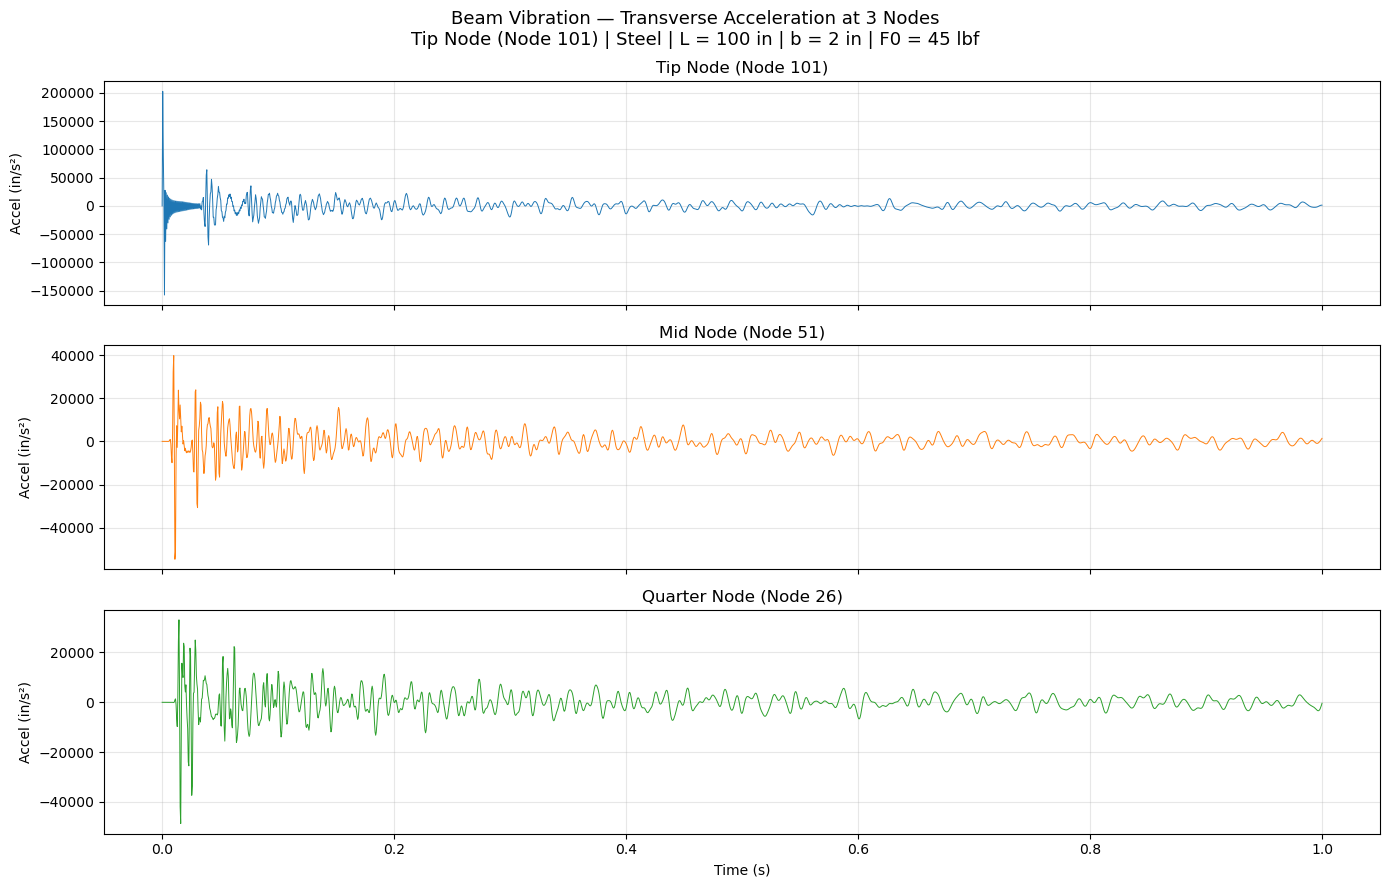

  Plot saved to: simulation_results\sample_simulation.png

 STEP 6 — Output files
  Location : c:\Users\G_Modak\Desktop\PhD work\Trial 26 Feb 2026\simulation_results

  Files created:
    sim_0000.csv to sim_2047.csv
    time_vector.csv
    sample_simulation.png

  Each CSV contains (Encoding C):
    - 2000 rows (one per timestep)
    - 17 metadata columns repeated on every row
    - time_s column
    - 101 node columns (node_001_accel to node_101_accel)

 PIPELINE COMPLETE


In [1]:

import time
import numpy as np
import matplotlib.pyplot as plt
import os
from importlib import reload

import sampling
reload(sampling)
from sampling      import generate_parameter_sets
from batch_runner  import run_batch
from exporter      import export_all_simulations, export_time_vector
from config        import DT, N_STEPS

# =============================================================
# CONFIGURATION
# =============================================================
OUTPUT_DIR    = 'simulation_results'   # folder for all CSV files
N_JOBS        = -1                     # -1 = use all CPU cores
SAMPLING_MODE = 1                      # 1 = discrete, 2 = continuous
ENCODING      = 'C'                    # A = serialized string per node (2 rows)
                                       # B = one column per node per timestep (2 rows, very wide)
                                       # C = one row per timestep, 2000 rows x 101 node cols

# =============================================================
# STEP 1 — GENERATE PARAMETER SETS
# =============================================================
print("=" * 60)
print(" STEP 1 — Generating parameter sets")
print("=" * 60)

param_sets = generate_parameter_sets(mode=SAMPLING_MODE)

print(f"  Parameter sets ready  : {len(param_sets)}")
print()
print("  Sample of first 3 simulations:")
for p in param_sets[:3]:
    print(f"    sim {p['sim_id']:03d} | "
          f"{p['material']:<10} | "
          f"L={p['length_in']:5.0f} in | "
          f"b={p['width_in']:.1f} in | "
          f"F0={p['impact_F0_lbf']:5.0f} lbf")
print()

# =============================================================
# STEP 2 — RUN FULL BATCH IN PARALLEL
# =============================================================
print("=" * 60)
print(" STEP 2 — Running simulations in parallel")
print("=" * 60)
print(f"  Total simulations : {len(param_sets)}")
print(f"  CPU cores         : {N_JOBS} (-1 = all available)")
print()

start_time = time.time()

results, n_success, n_failed = run_batch(param_sets, n_jobs=N_JOBS)

elapsed      = time.time() - start_time
time_per_sim = elapsed / len(param_sets)

print()
print(f"  Total time        : {round(elapsed, 2)} s  "
      f"({round(elapsed/60, 2)} min)")
print(f"  Time per sim      : {round(time_per_sim, 3)} s")
print(f"  Succeeded         : {n_success}")
print(f"  Failed            : {n_failed}")
print()

# =============================================================
# STEP 3 — EXPORT ONE CSV PER SIMULATION
# =============================================================
print("=" * 60)
print(" STEP 3 — Exporting one CSV per simulation")
print("=" * 60)

file_paths, n_exported, n_skipped = export_all_simulations(
    results,
    output_dir = OUTPUT_DIR,
    encoding   = ENCODING
)

print()
export_time_vector(output_dir=OUTPUT_DIR)

# =============================================================
# STEP 4 — Summary statistics
# =============================================================
print()
print("=" * 60)
print(" STEP 4 — Summary statistics")
print("=" * 60)
print(f"  Total simulations  : {len(results)}")
print(f"  Succeeded          : {n_success}")
print(f"  Failed             : {n_failed}")
print(f"  Files exported     : {n_exported}")
print(f"  Output folder      : {os.path.abspath(OUTPUT_DIR)}")
print()

materials = [r['params']['material']     for r in results if r['status'] == 'success']
lengths   = [r['params']['length_in']    for r in results if r['status'] == 'success']
widths    = [r['params']['width_in']     for r in results if r['status'] == 'success']
forces    = [r['params']['impact_F0_lbf'] for r in results if r['status'] == 'success']

print("  Material distribution:")
for mat in sorted(set(materials)):
    count = materials.count(mat)
    print(f"    {mat:<12} : {count} simulations")
print()

print("  Length distribution:")
for L in sorted(set(lengths)):
    count = lengths.count(L)
    print(f"    L = {L:5.0f} in  : {count} simulations")
print()

print("  Width distribution:")
for b in sorted(set(widths)):
    count = widths.count(b)
    print(f"    b = {b:.1f} in    : {count} simulations")
print()

print("  Force distribution:")
for F in sorted(set(forces)):
    count = forces.count(F)
    print(f"    F0 = {F:6.0f} lbf : {count} simulations")
print()

r0 = next(r for r in results if r['status'] == 'success')
print("  Example simulation (first success):")
for k, v in r0['params'].items():
    print(f"    {k:<20} : {v}")

# =============================================================
# STEP 5 — Plotting sample simulation
# =============================================================
print()
print("=" * 60)
print(" STEP 5 — Plotting sample simulation")
print("=" * 60)

node_accels = r0['node_accels']   # shape (101, N_STEPS)
time_vector = np.linspace(0, DT * (N_STEPS - 1), N_STEPS)
p           = r0['params']

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

fig.suptitle(
    "Beam Vibration — Transverse Acceleration at 3 Nodes\n"
    f"Tip Node (Node 101) | {p['material'].capitalize()} | "
    f"L = {p['length_in']:.0f} in | b = {p['width_in']:.0f} in | "
    f"F0 = {p['impact_F0_lbf']:.0f} lbf",
    fontsize=13
)

plot_nodes  = [100, 50, 25]
node_labels = ['Tip Node (Node 101)', 'Mid Node (Node 51)', 'Quarter Node (Node 26)']
colors      = ['tab:blue', 'tab:orange', 'tab:green']

for ax, node_idx, label, color in zip(axes, plot_nodes, node_labels, colors):
    ax.plot(time_vector, node_accels[node_idx, :], color=color, linewidth=0.7)
    ax.set_title(label)
    ax.set_ylabel("Accel (in/s²)")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, 'sample_simulation.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Plot saved to: {plot_path}")

# =============================================================
# STEP 6 — FINAL FILE SUMMARY
# =============================================================
print()
print("=" * 60)
print(" STEP 6 — Output files")
print("=" * 60)
print(f"  Location : {os.path.abspath(OUTPUT_DIR)}")
print()
print("  Files created:")
print(f"    sim_0000.csv to sim_{n_exported-1:04d}.csv")
print(f"    time_vector.csv")
print(f"    sample_simulation.png")
print()
if ENCODING == 'C':
    print("  Each CSV contains (Encoding C):")
    print(f"    - {N_STEPS} rows (one per timestep)")
    print(f"    - 17 metadata columns repeated on every row")
    print(f"    - time_s column")
    print(f"    - 101 node columns (node_001_accel to node_101_accel)")
elif ENCODING == 'A':
    print("  Each CSV contains (Encoding A):")
    print(f"    - 1 row")
    print(f"    - 17 metadata columns (beam parameters)")
    print(f"    - 101 node columns (node_001_accel to node_101_accel)")
    print(f"    - Each node column = {N_STEPS} acceleration values")
    print(f"      serialized as ';' delimited string")
print()
print("=" * 60)
print(" PIPELINE COMPLETE")
print("=" * 60)

 BEAM VIBRATION VISUALIZATION
Loaded  : sim_1000.csv
  Material   : steel
  Length     : 120.0 in
  Width      : 2.5 in
  Force      : 45.0 lbf
  n_nodes    : 101
  n_steps    : 2000
  dt         : 0.0005002501250625 s
  f_nyquist  : 999.5 Hz

  Frequency range : 1 Hz to 999.5 Hz
  X-axis scale    : log
  Y-axis scale    : linear

[1/6] Plotting time history...
Time history plot saved: simulation_results/plots\sim_1000_time_history.png


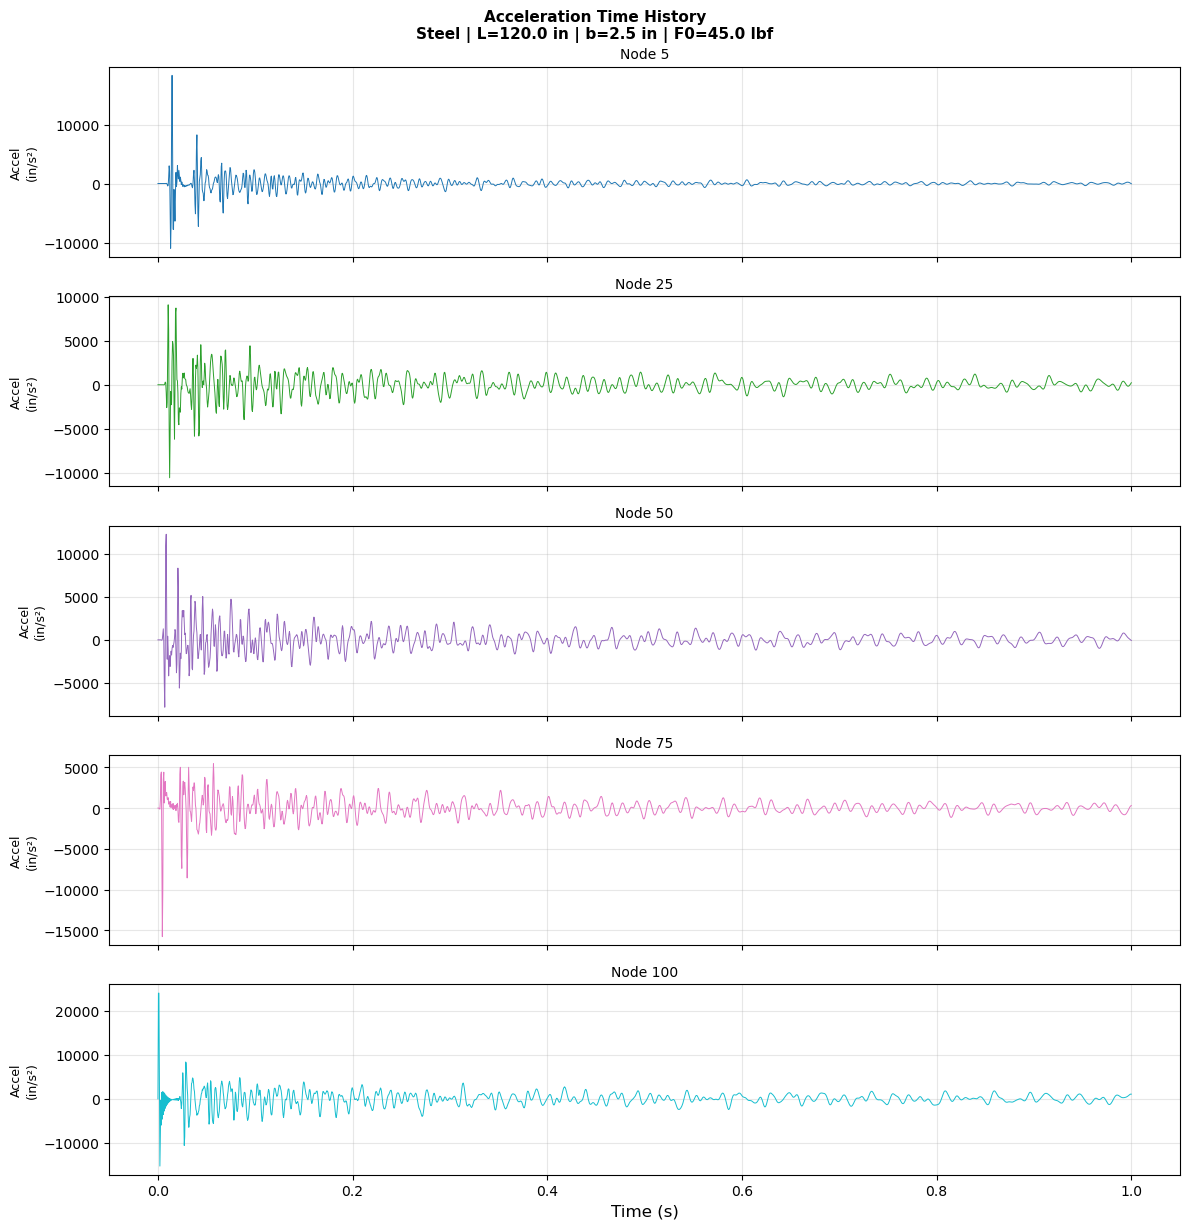


[2/6] Computing and plotting FFT...
FFT plot saved: simulation_results/plots\sim_1000_fft.png


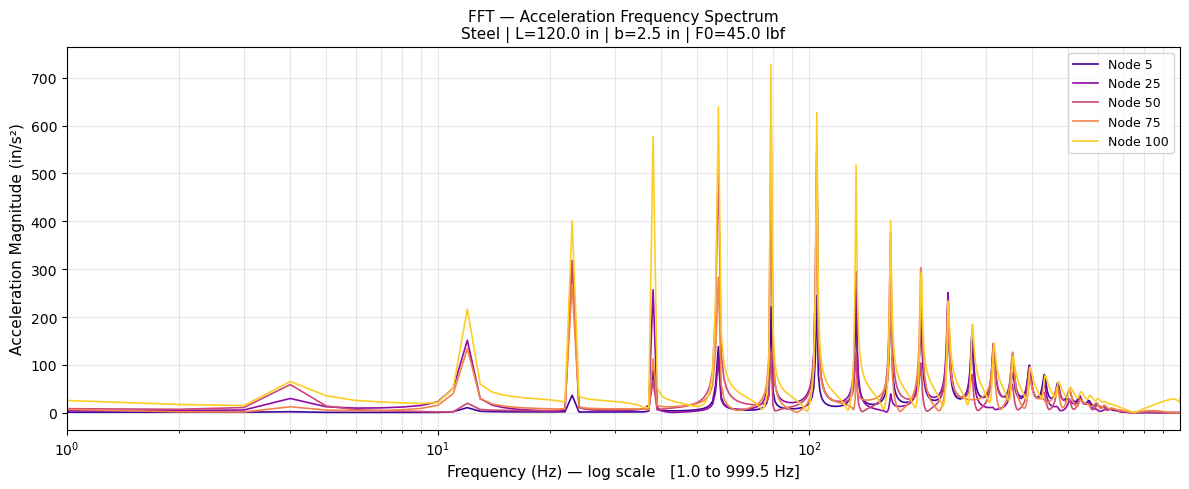


[3/6] Plotting FFT waterfall...
Waterfall plot saved: simulation_results/plots\sim_1000_fft_waterfall.png


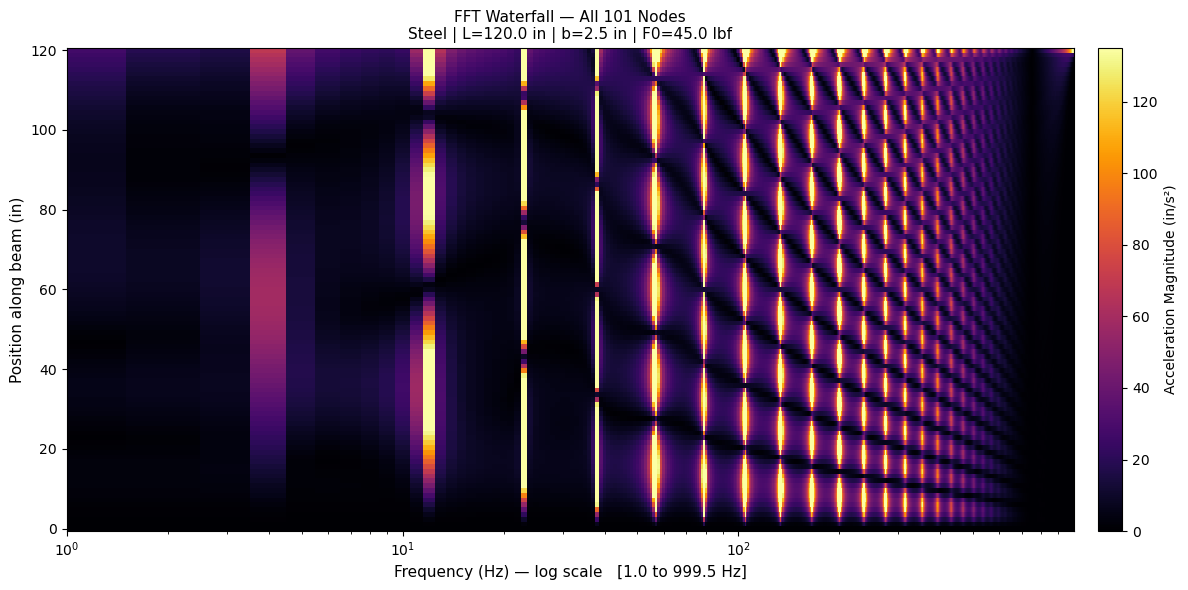


[4/6] Computing and plotting FRF...
FRF plot saved: simulation_results/plots\sim_1000_frf.png


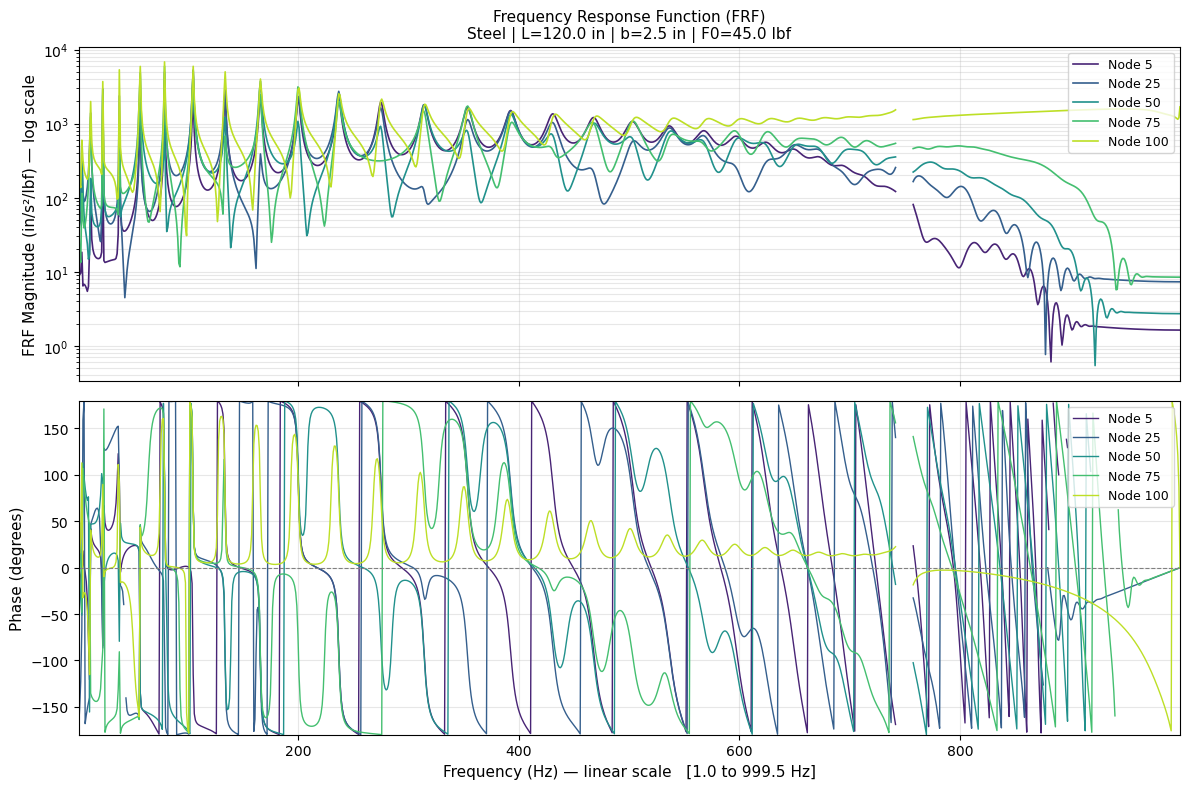


[5/6] Plotting per-node FRF and phase (600 Hz)...
Per-node FRF plot saved: simulation_results/plots\sim_1000_frf_per_node.png


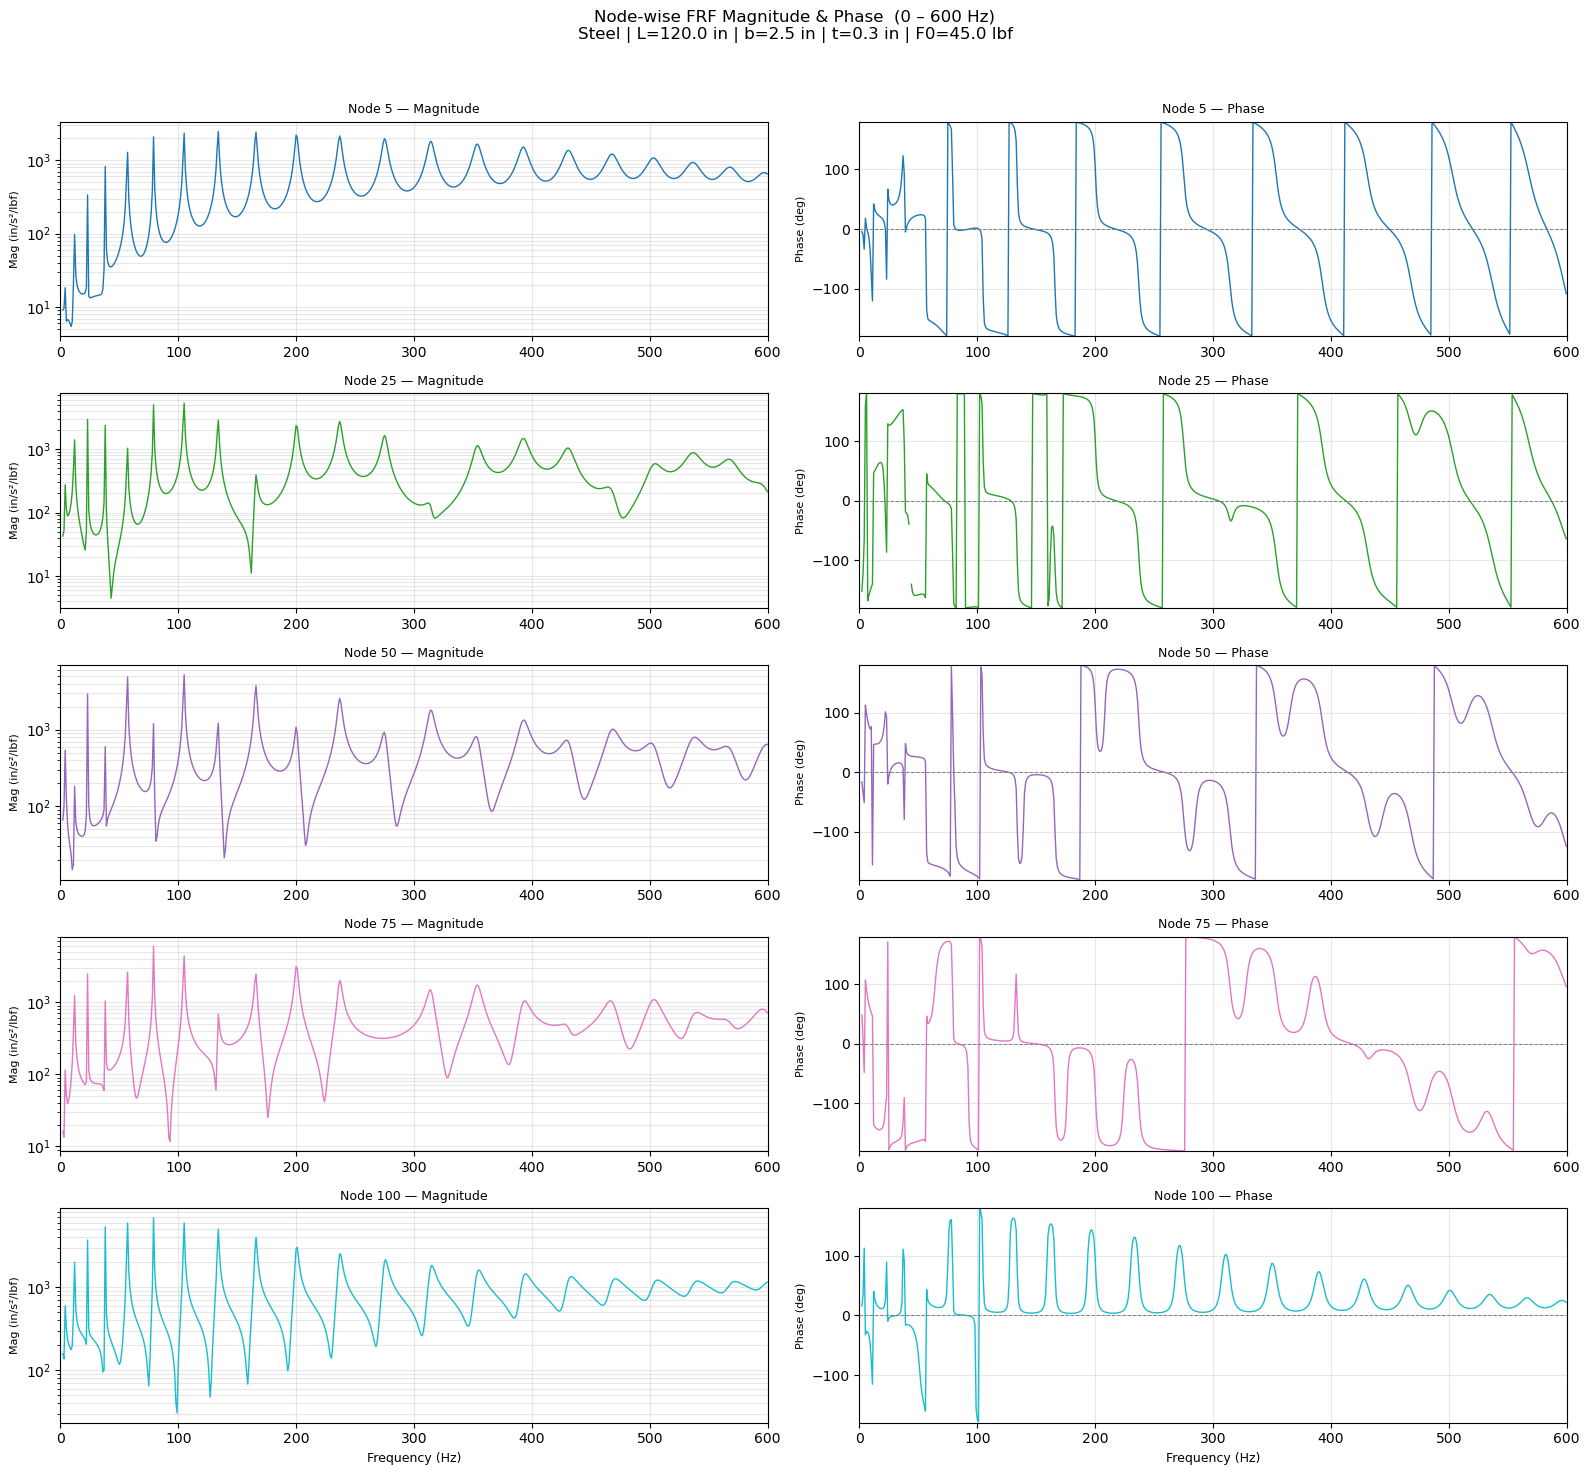


[6/6] Computing exact mode shapes via eigenvalue analysis...

Eigenvalue-based natural frequencies:
  Mode 1: 0.67 Hz
  Mode 2: 4.2 Hz
  Mode 3: 11.75 Hz
  Mode 4: 23.02 Hz
  Mode 5: 38.05 Hz
  Mode 6: 56.84 Hz
Mode shape plot saved: simulation_results/plots\sim_1000_mode_shapes.png


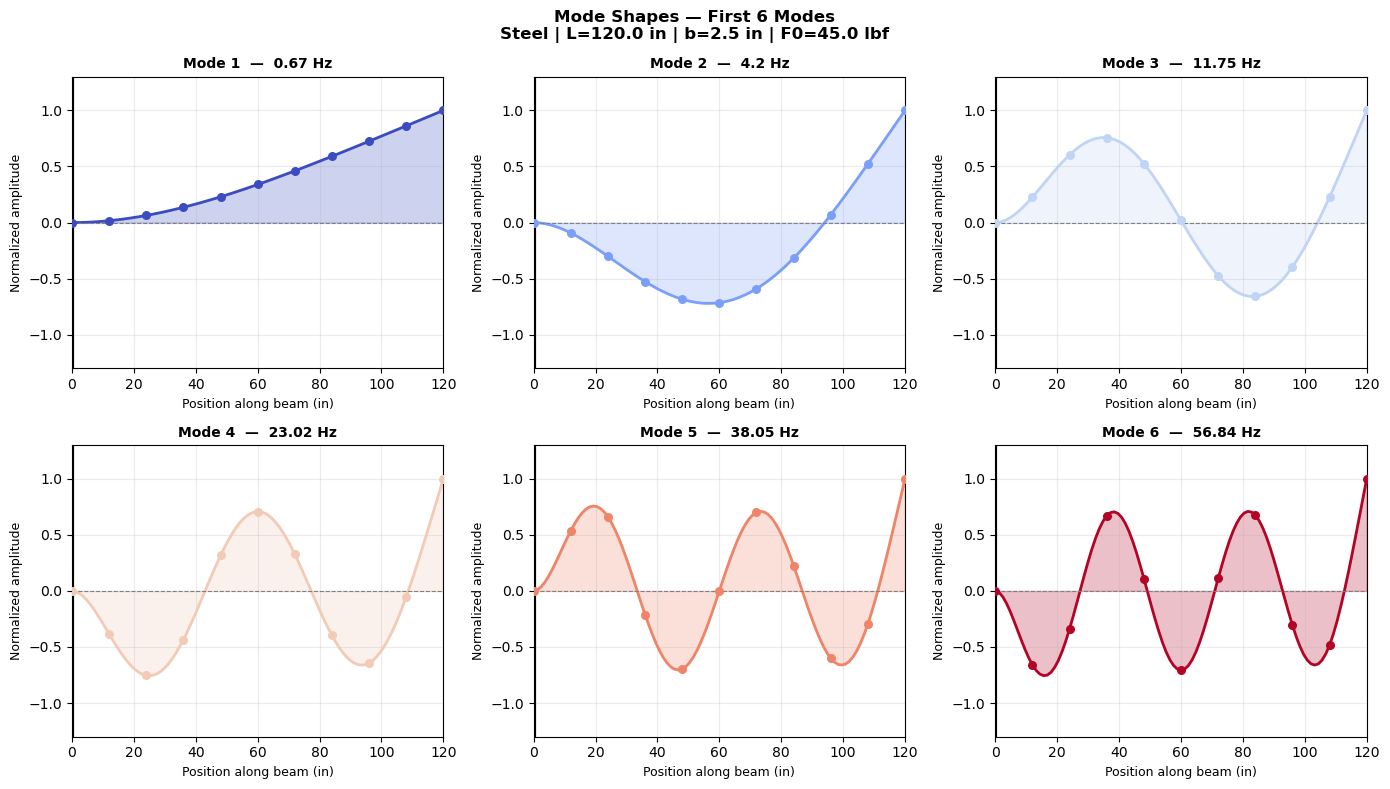


 VISUALIZATION COMPLETE  (6 plots)
 Plots saved to: c:\Users\G_Modak\Desktop\PhD work\Trial 26 Feb 2026\simulation_results\plots


In [3]:
from importlib import reload
import visualization
reload(visualization)
from visualization import run_visualization

run_visualization(
    csv_file_path = 'simulation_results/sim_1000.csv',
    output_dir    = 'simulation_results/plots',
    n_modes       = 6,
    nodes_to_plot = [4, 24, 49, 74, 99]   # Node 5, 25, 50, 75, 100 (Node 1 is fixed end)
)
